In [240]:
# Import the required libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

In [241]:
# First Step: read the dataset
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [242]:
# Second Step: Understanding the Dataset
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


| Column Name                | Description                                                      | Why It Is Important                                                                                |
| -------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| `age`                      | Age of the teenager.                                             | Helps analyze how mental health and social media habits change with age.                           |
| `gender`                   | Gender of the teenager (`male` / `female`).                      | Useful for comparing behavior and mental health patterns between genders.                          |
| `daily_social_media_hours` | Number of hours spent daily on social media.                     | Main feature used to study the impact of social media usage on mental health.                      |
| `platform_usage`           | Most used social media platform (`Instagram`, `TikTok`, `Both`). | Helps identify whether certain platforms are linked to higher stress or addiction levels.          |
| `sleep_hours`              | Average hours of sleep per day.                                  | Sleep strongly affects mental and physical health. Lower sleep may increase anxiety or depression. |
| `screen_time_before_sleep` | Hours spent using screens before sleeping.                       | High screen exposure before sleep can reduce sleep quality and increase stress.                    |
| `academic_performance`     | Academic score or performance level.                             | Used to study whether social media affects concentration and school performance.                   |
| `physical_activity`        | Amount of daily physical activity or exercise.                   | Physical activity is often linked to lower stress and better mental health.                        |
| `social_interaction_level` | Level of real-life social interaction (`low`, `medium`, `high`). | Measures how socially active the teenager is outside social media.                                 |
| `stress_level`             | Stress score or level.                                           | Indicates emotional pressure experienced by the teenager.                                          |
| `anxiety_level`            | Anxiety severity score.                                          | Used to measure nervousness, fear, or overthinking.                                                |
| `addiction_level`          | Social media addiction score.                                    | Shows how dependent the teenager may be on social media usage.                                     |
| `depression_label`         | Target column indicating depression risk (`0 = No`, `1 = Yes`).  | Main prediction target for machine learning models.                                                |


In [243]:
# Third Step: Exploratory Data Analysis (EDA)
df.shape

(1200, 13)

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [245]:
df.isna().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [246]:
df.duplicated().sum()

np.int64(0)

In [247]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [248]:
df.select_dtypes(include="number").median()

age                         16.00
daily_social_media_hours     4.50
sleep_hours                  6.50
screen_time_before_sleep     1.80
academic_performance         2.99
physical_activity            1.00
stress_level                 5.00
anxiety_level                6.00
addiction_level              6.00
depression_label             0.00
dtype: float64

In [249]:
df.describe(include="object")

,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [250]:
# Check class imbalance
df["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

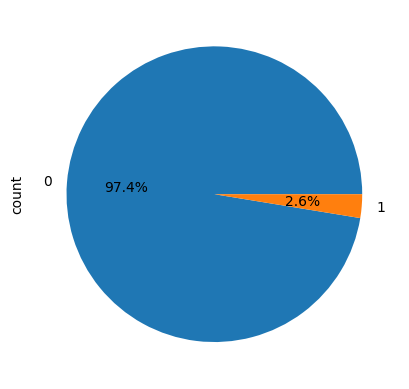

In [251]:
df["depression_label"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()

In [252]:
col_num = df.select_dtypes(include="number").columns
col_cat = df.select_dtypes(include="object").columns

In [253]:
for cat in col_cat:
    print(f"Column: {cat}")

    print("Unique Values:")
    print(pd.unique(df[cat]))

    print("\nNumber of Unique Values:")
    print(df[cat].nunique())

    print("\nValue Counts:")
    print(df[cat].value_counts())

    print("-" * 30)

Column: gender
Unique Values:
['male' 'female']

Number of Unique Values:
2

Value Counts:
gender
male      615
female    585
Name: count, dtype: int64
------------------------------
Column: platform_usage
Unique Values:
['Instagram' 'TikTok' 'Both']

Number of Unique Values:
3

Value Counts:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64
------------------------------
Column: social_interaction_level
Unique Values:
['low' 'high' 'medium']

Number of Unique Values:
3

Value Counts:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64
------------------------------


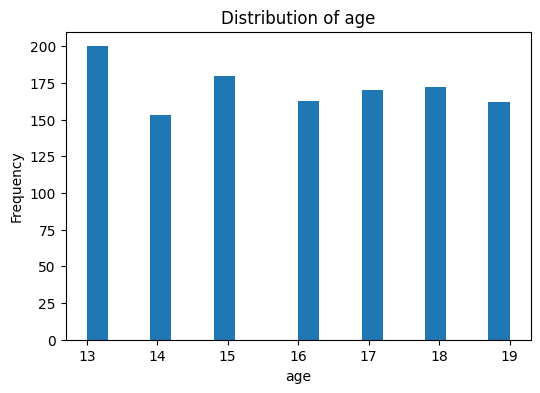

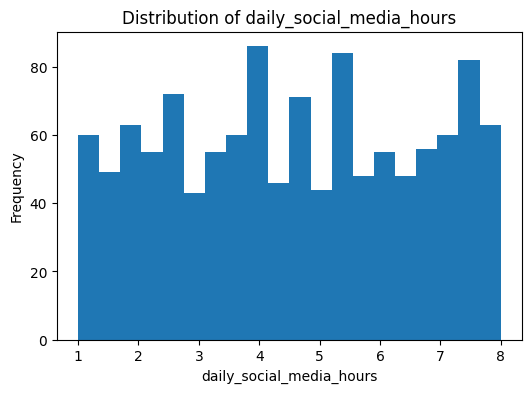

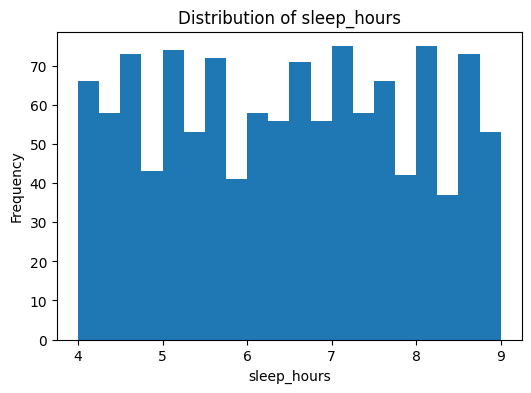

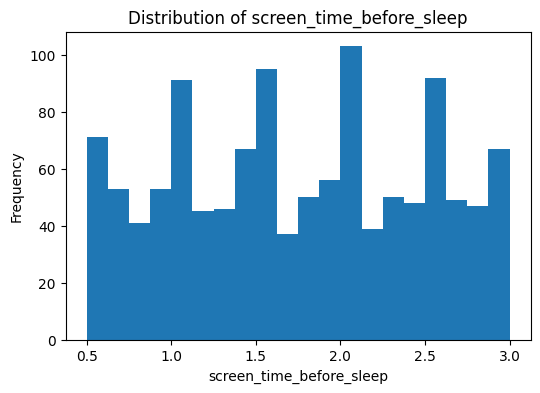

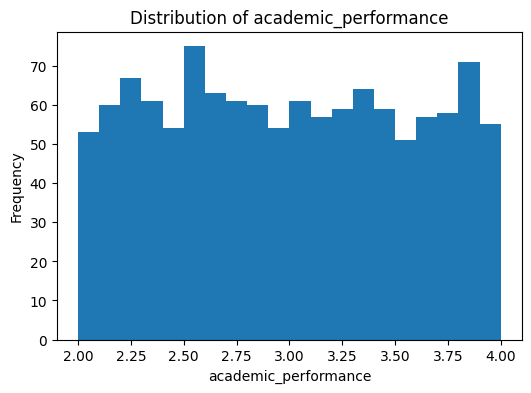

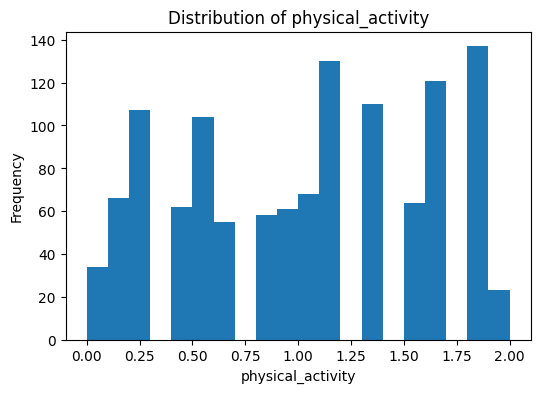

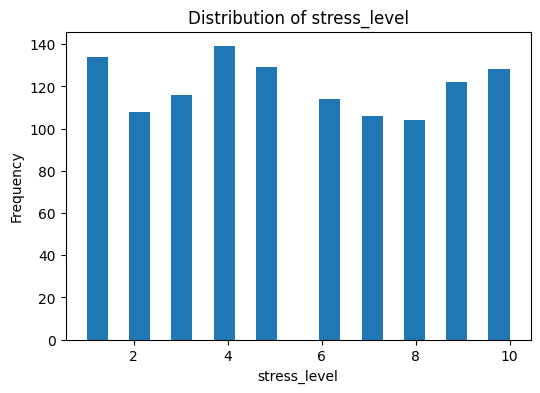

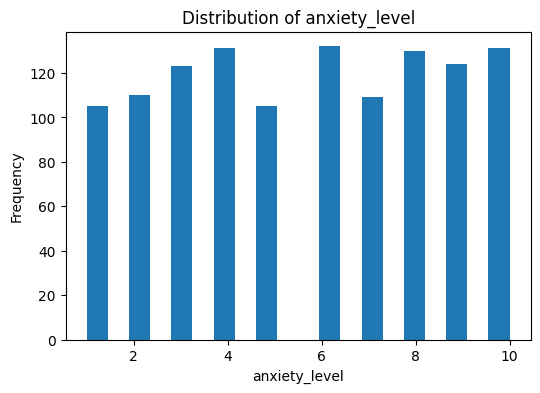

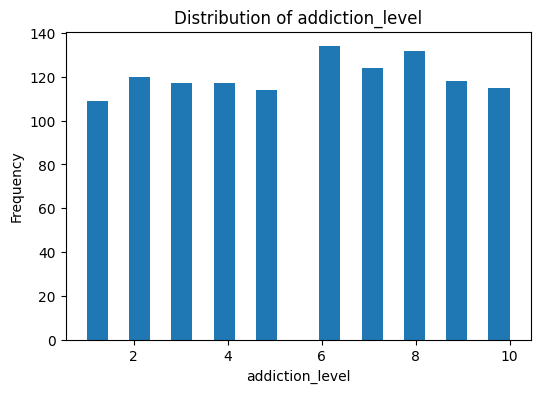

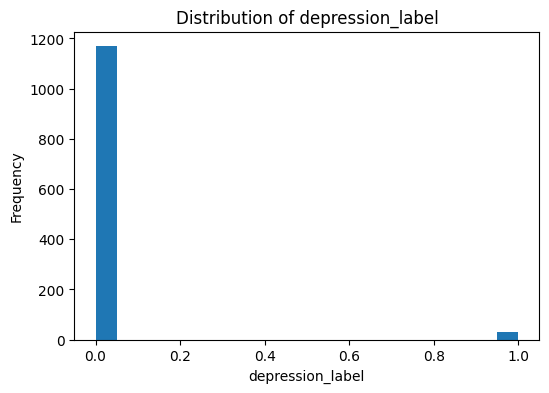

In [254]:
for num in col_num:
    plt.figure(figsize=(6,4))

    plt.hist(df[num], bins=20)

    plt.title(f"Distribution of {num}")
    plt.xlabel(num)
    plt.ylabel("Frequency")

    plt.show()

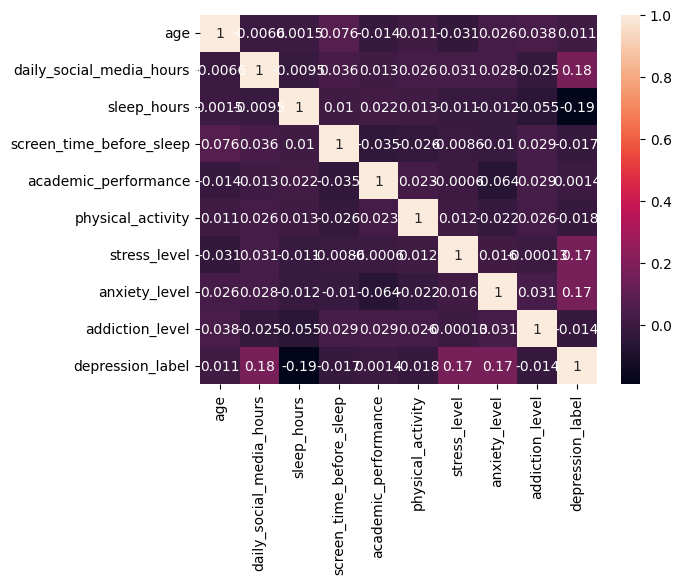

In [255]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [256]:
df.corr(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


In [257]:
# Calculate the average of numerical features grouped by depression label
df.groupby("depression_label")[col_num].mean()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
depression_label,,,,,,,,,,
0,15.924722,4.478785,6.494183,1.742258,2.990248,1.016168,5.365269,5.557742,5.571429,0.0
1,16.064516,6.719355,4.761290,1.667742,2.995484,0.951613,8.483871,8.612903,5.322581,1.0


In [258]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [259]:
df.groupby('gender')['daily_social_media_hours'].sum()

gender
female    2640.1
male      2803.9
Name: daily_social_media_hours, dtype: float64

In [260]:
df.groupby("platform_usage")["age"].count()

platform_usage
Both         391
Instagram    411
TikTok       398
Name: age, dtype: int64

In [261]:
df.groupby('depression_label')['sleep_hours'].agg(['mean', 'sum', 'min', 'max'])

,mean,sum,min,max
depression_label,,,,
0,6.494183,7591.7,4.0,9.0
1,4.761290,147.6,4.1,5.8


In [262]:
# Fourth Step: Feature Engineering

In [263]:
# Fifth Step: Data Preprocessing

In [264]:
# Split the dataset into features (X) and target (y)
y = df["depression_label"]

X = df.drop("depression_label", axis=1)

In [265]:
from sklearn.model_selection import train_test_split
x_tran , x_test , y_train , y_test = train_test_split(X , y ,test_size=0.2 , random_state=111 , shuffle=True)

In [266]:
x_tran.shape, x_test.shape , y_train.shape , y_test.shape

((960, 12), (240, 12), (960,), (240,))

In [267]:
# Build a machine learning pipeline for preprocessing and model training

In [268]:
col_cat

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')

In [269]:
from sklearn.preprocessing import OneHotEncoder 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# One-Hot Encoding for categorical variables
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

pipeline_ohe = ColumnTransformer(transformers=[
    ("OneHotEncoder" ,ohe , col_cat)
], remainder="passthrough")
pipeline_ohe

,transformers,"[('OneHotEncoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB 
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate

models = {
    "Logistic Regression": Pipeline(steps=[("pre", pipeline_ohe), ("clf", LogisticRegression())]),
    "Decision Tree":       Pipeline(steps=[("pre", pipeline_ohe), ("clf", DecisionTreeClassifier(random_state=111))]),
    "Random Forest":       Pipeline(steps=[("pre", pipeline_ohe), ("clf", RandomForestClassifier(random_state=111))]),
    "GradientBoosting Classifier": Pipeline(steps=[("pre", pipeline_ohe), ("clf", GradientBoostingClassifier(random_state=111))]),
    "GaussianNB":          Pipeline(steps=[("pre", pipeline_ohe), ("clf", GaussianNB())]),
    "CatBoostClassifier":  Pipeline(steps=[("pre", pipeline_ohe), ("clf", CatBoostClassifier(random_state=111, verbose=0))])


In [271]:
summary_data = []

for name, model_pipeline in models.items():
    cv_results = cross_validate(model_pipeline, x_tran, y_train, cv=5, scoring=["f1", "accuracy"])
    
    summary_data.append({
        "Model": name,
        "Mean Test Accuracy": cv_results["test_accuracy"].mean(),
        "Mean Test F1": cv_results["test_f1"].mean()
    })

df_results = pd.DataFrame(summary_data)
df_results = df_results.sort_values(by="Mean Test F1", ascending=False)
print(df_results)

/home/yousef/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                         Model  Mean Test Accuracy  Mean Test F1
1                Decision Tree            1.000000      1.000000
3  GradientBoosting Classifier            0.998958      0.977778
5           CatBoostClassifier            0.998958      0.977778
0          Logistic Regression            0.982292      0.629091
4                   GaussianNB            0.984375      0.604762
2                Random Forest            0.973958      0.066667



 Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       235
           1       1.00      0.80      0.89         5

    accuracy                           1.00       240
   macro avg       1.00      0.90      0.94       240
weighted avg       1.00      1.00      1.00       240



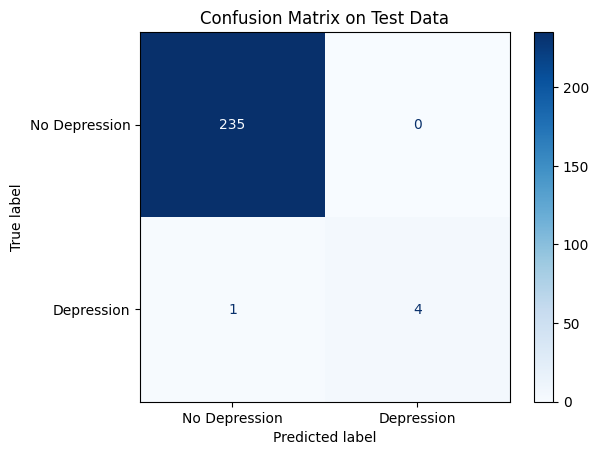

In [272]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = models["GradientBoosting Classifier"]
best_model.fit(x_tran, y_train)

y_pred = best_model.predict(x_test)

print("\n Final Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Depression", "Depression"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Data")
plt.show()


 Final Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       235
           1       1.00      0.80      0.89         5

    accuracy                           1.00       240
   macro avg       1.00      0.90      0.94       240
weighted avg       1.00      1.00      1.00       240



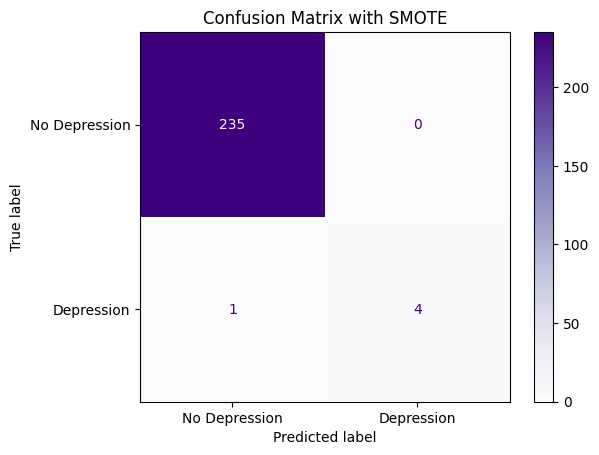

In [273]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

smote_model = ImbPipeline(steps=[
    ("pre", pipeline_ohe),              
    ("smote", SMOTE(random_state=111)),   
    ("clf", GradientBoostingClassifier(random_state=111)) 
])

smote_model.fit(x_tran, y_train)

y_pred_smote = smote_model.predict(x_test)

print("\n Final Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_smote))

cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Depression", "Depression"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix with SMOTE")
plt.show()